In [ ]:
print('hello world')

hello world


In [ ]:
import pandas as pd


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f9f9f9'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✓ Libraries loaded")

✓ Libraries loaded


In [ ]:
df_raw = pd.read_csv('swiggy.csv')   # change path if needed

print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(3)

Raw dataset shape: (8680, 10)
Columns: ['ID', 'Area', 'City', 'Restaurant', 'Price', 'Avg ratings', 'Total ratings', 'Food type', 'Address', 'Delivery time']


,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50


In [ ]:
# Check what's in primary_cuisine
print(df['primary_cuisine'].value_counts().head(30))

primary_cuisine
North Indian     1109
Indian           1012
Chinese           991
Fast Food         604
South Indian      464
Biryani           424
Desserts          335
Beverages         296
Pizzas            272
Bakery            255
Ice Cream         220
Italian           189
Snacks            187
Continental       186
American          134
Sweets            100
Mughlai            89
Street Food        85
Arabian            81
Punjabi            75
Healthy Food       73
Bengali            71
Asian              57
Chaat              55
Maharashtrian      51
Juices             49
Combo              37
Mexican            34
Thalis             31
Cafe               31
Name: count, dtype: int64


In [ ]:
df = df_raw.copy()

print("BEFORE CLEANING:")
print(f"  Rows: {len(df)}")
print(f"  Nulls: {df.isnull().sum().sum()}")
print(f"  Duplicates: {df.duplicated().sum()}")

BEFORE CLEANING:
  Rows: 8680
  Nulls: 0
  Duplicates: 0


In [ ]:
df.columns = [
    'id', 'area', 'city', 'restaurant',
    'price', 'avg_rating', 'total_ratings',
    'food_type', 'address', 'delivery_time'
]

In [ ]:
zero_price = (df['price'] == 0).sum()
df = df[df['price'] > 0]
print(f"\n  Dropped {zero_price} rows with Price = 0")


  Dropped 5 rows with Price = 0


In [ ]:
price_outliers = (df['price'] > 2000).sum()
df['price'] = df['price'].clip(upper=2000)
print(f"  Capped {price_outliers} rows with Price > 2000")

  Capped 3 rows with Price > 2000


In [ ]:
delivery_outliers = (df['delivery_time'] > 90).sum()
df['delivery_time'] = df['delivery_time'].clip(upper=90)
print(f"  Capped {delivery_outliers} rows with Delivery time > 90 mins")

  Capped 60 rows with Delivery time > 90 mins


In [ ]:
df['price'] = df['price'].astype(int)
df['delivery_time'] = df['delivery_time'].astype(int)


In [ ]:
print(f"\nAFTER CLEANING:")
print(f"  Rows: {len(df)}")
print(f"  Nulls: {df.isnull().sum().sum()}")
print("✓ Data cleaning complete")


AFTER CLEANING:
  Rows: 8675
  Nulls: 0
✓ Data cleaning complete


In [ ]:
df['primary_cuisine'] = df['food_type'].str.split(',').str[0].str.strip()

In [ ]:
def rate_category(r):
    if r >= 4.5:   return 'Excellent'
    elif r >= 4.0: return 'Good'
    elif r >= 3.5: return 'Average'
    else:          return 'Poor'

df['rating_category'] = df['avg_rating'].apply(rate_category)

In [ ]:
df['rating_confidence'] = df['total_ratings'].apply(
    lambda x: 'High' if x >= 50 else 'Low'
)

In [ ]:
def price_segment(p):
    if p <= 200:   return 'Budget (≤₹200)'
    elif p <= 400: return 'Mid-Range (₹201–400)'
    elif p <= 700: return 'Premium (₹401–700)'
    else:          return 'Luxury (>₹700)'

df['price_segment'] = df['price'].apply(price_segment)

In [ ]:
def delivery_speed(t):
    if t <= 30:    return 'Fast (≤30 min)'
    elif t <= 45:  return 'On-Time (31–45 min)'
    elif t <= 60:  return 'Delayed (46–60 min)'
    else:          return 'Very Delayed (>60 min)'

df['delivery_speed'] = df['delivery_time'].apply(delivery_speed)

In [ ]:
df['sla_breach'] = (df['delivery_time'] > 45).map({True: 'Breach', False: 'On Track'})

In [ ]:
df['underperforming'] = (
    (df['avg_rating'] < 3.5) & (df['delivery_time'] > 45)
).map({True: 'Yes', False: 'No'})

print("New columns created:")
print(df[['restaurant', 'primary_cuisine', 'rating_category',
          'price_segment', 'delivery_speed', 'sla_breach',
          'underperforming']].head(5).to_string())
print(f"\n✓ Derived columns complete — dataset now has {len(df.columns)} columns")

New columns created:
          restaurant primary_cuisine rating_category         price_segment          delivery_speed sla_breach underperforming
0        Tandoor Hut         Biryani            Good  Mid-Range (₹201–400)     Delayed (46–60 min)     Breach              No
1      Tunday Kababi         Mughlai            Good  Mid-Range (₹201–400)     Delayed (46–60 min)     Breach              No
2            Kim Lee         Chinese            Good    Premium (₹401–700)     Delayed (46–60 min)     Breach              No
3  New Punjabi Hotel    North Indian         Average  Mid-Range (₹201–400)     Delayed (46–60 min)     Breach              No
4                Nh8      Rajasthani            Good  Mid-Range (₹201–400)  Very Delayed (>60 min)     Breach              No

✓ Derived columns complete — dataset now has 17 columns


In [ ]:
print("=" * 55)
print("KEY INSIGHTS FROM CLEANED DATA")
print("=" * 55)

total = len(df)
breach = (df['sla_breach'] == 'Breach').sum()
poor   = (df['rating_category'] == 'Poor').sum()
under  = (df['underperforming'] == 'Yes').sum()
low_conf = (df['rating_confidence'] == 'Low').sum()

print(f"Total restaurants      : {total:,}")
print(f"Cities covered         : {df['city'].nunique()}")
print(f"Avg rating             : {df['avg_rating'].mean():.2f} / 5.0")
print(f"Avg delivery time      : {df['delivery_time'].mean():.1f} mins")
print(f"Avg price              : ₹{df['price'].mean():.0f}")
print(f"SLA breach (>45 min)   : {breach:,} ({breach/total*100:.1f}%)")
print(f"Poor rated (<3.5)      : {poor:,} ({poor/total*100:.1f}%)")
print(f"Underperforming        : {under:,} ({under/total*100:.1f}%)")
print(f"Low confidence ratings : {low_conf:,} ({low_conf/total*100:.1f}%)")
print("=" * 55)

KEY INSIGHTS FROM CLEANED DATA
Total restaurants      : 8,675
Cities covered         : 9
Avg rating             : 3.66 / 5.0
Avg delivery time      : 53.9 mins
Avg price              : ₹348
SLA breach (>45 min)   : 6,115 (70.5%)
Poor rated (<3.5)      : 3,519 (40.6%)
Underperforming        : 2,700 (31.1%)
Low confidence ratings : 1,438 (16.6%)


In [ ]:
df.to_csv('swiggy_clean.csv', index=False)
print(f"✓ Saved: swiggy_clean.csv ({len(df)} rows, {len(df.columns)} columns)")

# Auto-download in Colab
try:
    from google.colab import files
    files.download('swiggy_clean.csv')
    print("✓ Download triggered!")
except:
    print("  (Download the file manually from the Files panel)")

✓ Saved: swiggy_clean.csv (8675 rows, 17 columns)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download triggered!


In [ ]:
# Swiggy brand colors
ORANGE  = '#FC8019'
DARK    = '#1C1C1C'
GRAY    = '#7C7C7C'
LIGHT   = '#FFF3E8'
COLORS  = ['#FC8019','#F4A636','#EBC84A','#60B246','#3A7BD5','#9B59B6','#E74C3C','#1ABC9C','#34495E']

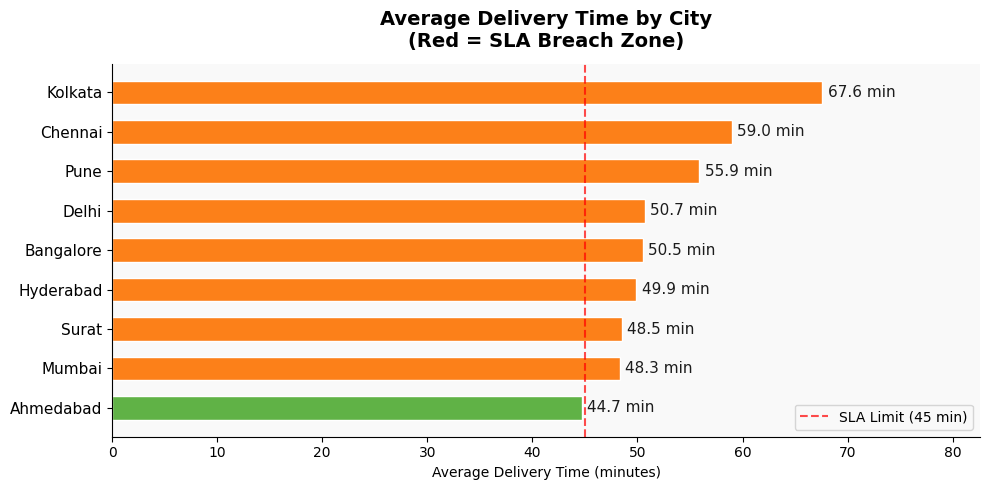

✓ Chart 1 saved: Avg Delivery Time by City


In [ ]:

# ── CHART 1 — Avg Delivery Time by City ──────────────────────
# KEY INSIGHT: Which cities are failing Swiggy's 30-min promise?

fig, ax = plt.subplots(figsize=(10, 5))

city_delivery = (df.groupby('city')['delivery_time']
                   .mean()
                   .sort_values(ascending=True)
                   .round(1))

bars = ax.barh(city_delivery.index, city_delivery.values,
               color=[ORANGE if v > 45 else '#60B246' for v in city_delivery.values],
               edgecolor='white', height=0.6)

# Add value labels
for bar, val in zip(bars, city_delivery.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val} min', va='center', fontsize=11, color=DARK)

# Reference line at 45 min SLA
ax.axvline(x=45, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='SLA Limit (45 min)')

ax.set_title('Average Delivery Time by City\n(Red = SLA Breach Zone)', pad=12)
ax.set_xlabel('Average Delivery Time (minutes)')
ax.set_xlim(0, city_delivery.max() + 15)
ax.legend(fontsize=10)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.savefig('chart1_delivery_by_city.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 1 saved: Avg Delivery Time by City")

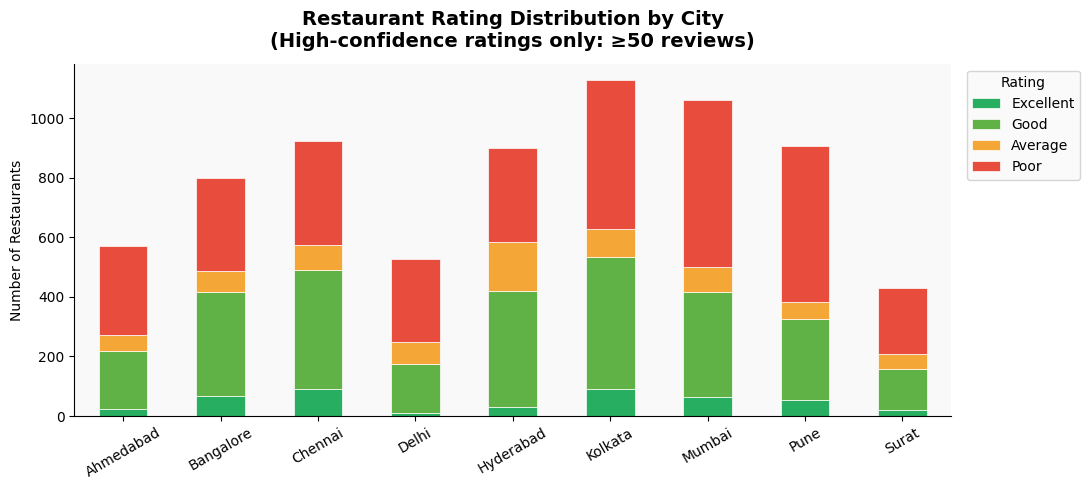

✓ Chart 2 saved: Rating Distribution by City


In [ ]:
# ── CHART 2 — Rating Distribution by City ────────────────────
# KEY INSIGHT: Which city has the most Poor-rated restaurants?

fig, ax = plt.subplots(figsize=(11, 5))

rating_city = (df[df['rating_confidence'] == 'High']   # only high-confidence ratings
                 .groupby(['city', 'rating_category'])
                 .size()
                 .unstack(fill_value=0))

# Reorder columns for stacked bar
col_order = ['Excellent', 'Good', 'Average', 'Poor']
col_order = [c for c in col_order if c in rating_city.columns]
rating_city = rating_city[col_order]

colors_rating = {'Excellent': '#27AE60', 'Good': '#60B246',
                 'Average':   '#F4A636', 'Poor':  '#E74C3C'}

rating_city.plot(kind='bar', stacked=True, ax=ax,
                 color=[colors_rating[c] for c in col_order],
                 edgecolor='white', linewidth=0.5)

ax.set_title('Restaurant Rating Distribution by City\n(High-confidence ratings only: ≥50 reviews)', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Number of Restaurants')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Rating', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('chart2_rating_by_city.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 2 saved: Rating Distribution by City")

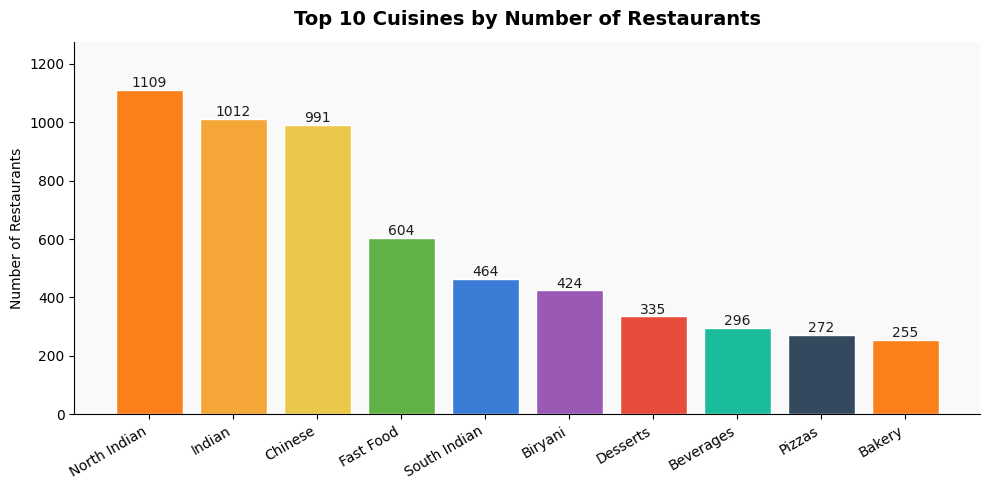

✓ Chart 3 saved: Top 10 Cuisines


In [ ]:
# ── CHART 3 — Top 10 Cuisines by Restaurant Count ────────────
# KEY INSIGHT: What cuisine types dominate the Swiggy platform?

fig, ax = plt.subplots(figsize=(10, 5))

top_cuisines = df['primary_cuisine'].value_counts().head(10)

bars = ax.bar(range(len(top_cuisines)), top_cuisines.values,
              color=COLORS[:10], edgecolor='white')

# Value labels on top of bars
for bar, val in zip(bars, top_cuisines.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', fontsize=10, color=DARK)

ax.set_title('Top 10 Cuisines by Number of Restaurants', pad=12)
ax.set_ylabel('Number of Restaurants')
ax.set_xticks(range(len(top_cuisines)))
ax.set_xticklabels(top_cuisines.index, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, top_cuisines.max() * 1.15)

plt.tight_layout()
plt.savefig('chart3_top_cuisines.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 3 saved: Top 10 Cuisines")


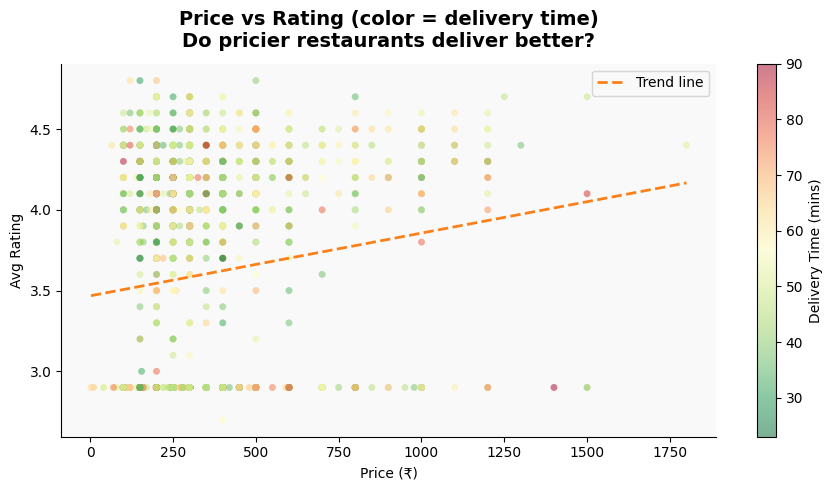

✓ Chart 4 saved: Price vs Rating Scatter


In [ ]:
# ── CHART 4 — Price vs Rating Scatter ────────────────────────
# KEY INSIGHT: Do expensive restaurants actually get better ratings?

fig, ax = plt.subplots(figsize=(9, 5))

# Sample 2000 points to avoid overcrowding
sample = df[df['rating_confidence'] == 'High'].sample(
    min(2000, len(df[df['rating_confidence'] == 'High'])), random_state=42
)

scatter = ax.scatter(
    sample['price'], sample['avg_rating'],
    c=sample['delivery_time'], cmap='RdYlGn_r',
    alpha=0.5, s=25, edgecolors='none'
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Delivery Time (mins)', fontsize=10)

# Trend line
z = np.polyfit(sample['price'], sample['avg_rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['price'].min(), sample['price'].max(), 100)
ax.plot(x_line, p(x_line), color=ORANGE, linewidth=2, linestyle='--', label='Trend line')

ax.set_title('Price vs Rating (color = delivery time)\nDo pricier restaurants deliver better?', pad=12)
ax.set_xlabel('Price (₹)')
ax.set_ylabel('Avg Rating')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart4_price_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 4 saved: Price vs Rating Scatter")


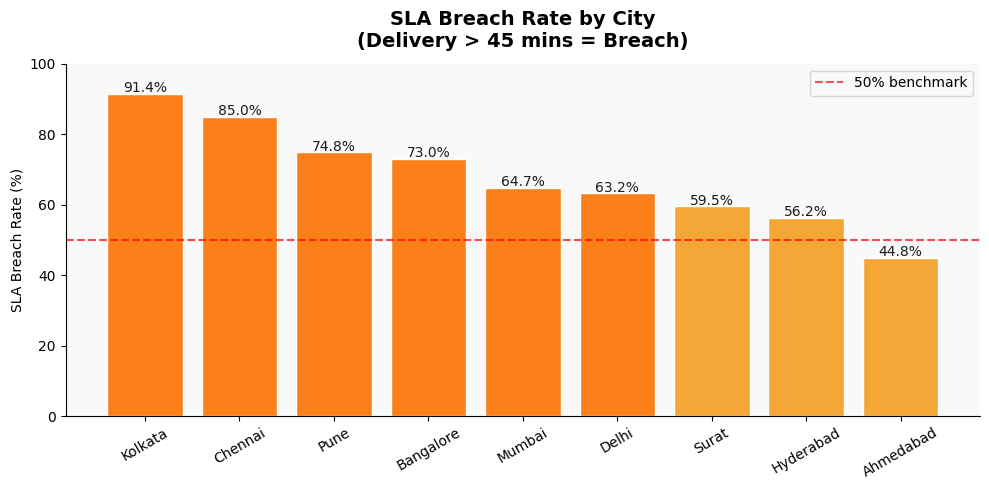

✓ Chart 5 saved: SLA Breach by City


In [ ]:
# ── CHART 5 — SLA Breach % by City ───────────────────────────
# KEY INSIGHT: Which cities need last-mile delivery improvement?

fig, ax = plt.subplots(figsize=(10, 5))

sla_city = (df.groupby('city')
              .apply(lambda x: (x['sla_breach'] == 'Breach').mean() * 100)
              .sort_values(ascending=False)
              .round(1))

bars = ax.bar(sla_city.index, sla_city.values,
              color=[ORANGE if v > 60 else '#F4A636' if v > 40 else '#60B246'
                     for v in sla_city.values],
              edgecolor='white')

# Value labels
for bar, val in zip(bars, sla_city.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=10, color=DARK)

# Reference line at 50%
ax.axhline(y=50, color='red', linestyle='--', linewidth=1.5,
           alpha=0.7, label='50% benchmark')

ax.set_title('SLA Breach Rate by City\n(Delivery > 45 mins = Breach)', pad=12)
ax.set_ylabel('SLA Breach Rate (%)')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart5_sla_breach_by_city.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 5 saved: SLA Breach by City")


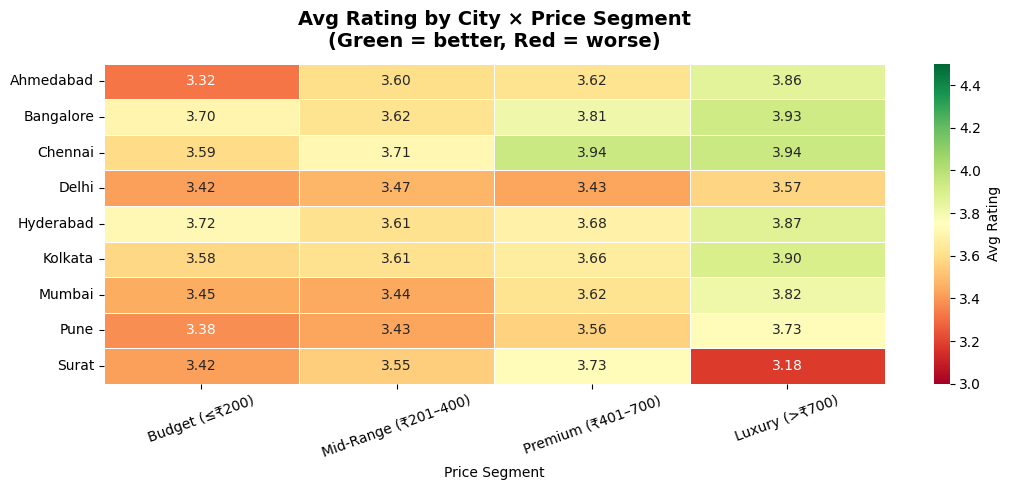

✓ Chart 6 saved: Rating Heatmap


In [ ]:
# ── CHART 6 — Avg Rating by Price Segment & City (Heatmap) ───
# KEY INSIGHT: Which city + price combo has the worst performance?

fig, ax = plt.subplots(figsize=(11, 5))

seg_order = ['Budget (≤₹200)', 'Mid-Range (₹201–400)',
             'Premium (₹401–700)', 'Luxury (>₹700)']

heatmap_data = (df[df['rating_confidence'] == 'High']
                  .groupby(['city', 'price_segment'])['avg_rating']
                  .mean()
                  .unstack()
                  .reindex(columns=[s for s in seg_order
                                    if s in df['price_segment'].unique()])
                  .round(2))

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=3.0, vmax=4.5, ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Avg Rating'})

ax.set_title('Avg Rating by City × Price Segment\n(Green = better, Red = worse)', pad=12)
ax.set_xlabel('Price Segment')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('chart6_rating_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart 6 saved: Rating Heatmap")

In [ ]:
# ── FINAL SUMMARY ─────────────────────────────────────────────

print("\n" + "=" * 55)
print("DAY 2 COMPLETE — FILES SAVED:")
print("=" * 55)
print("  swiggy_clean.csv           ← cleaned dataset for Power BI")
print("  chart1_delivery_by_city    ← delivery time analysis")
print("  chart2_rating_by_city      ← rating distribution")
print("  chart3_top_cuisines        ← cuisine breakdown")
print("  chart4_price_vs_rating     ← price vs quality scatter")
print("  chart5_sla_breach_by_city  ← SLA performance by city")
print("  chart6_rating_heatmap      ← city x price heatmap")
print("\nNext step → Day 3: Load swiggy_clean.csv into Power BI")
print("=" * 55)



DAY 2 COMPLETE — FILES SAVED:
  swiggy_clean.csv           ← cleaned dataset for Power BI
  chart1_delivery_by_city    ← delivery time analysis
  chart2_rating_by_city      ← rating distribution
  chart3_top_cuisines        ← cuisine breakdown
  chart4_price_vs_rating     ← price vs quality scatter
  chart5_sla_breach_by_city  ← SLA performance by city
  chart6_rating_heatmap      ← city x price heatmap

Next step → Day 3: Load swiggy_clean.csv into Power BI


In [ ]:
# Group smaller cuisines into broader categories
cuisine_map = {
    'North Indian': 'North Indian',
    'Indian': 'North Indian',
    'Mughlai': 'North Indian',
    'Punjabi': 'North Indian',
    'Bengali': 'North Indian',
    'Maharashtrian': 'North Indian',
    'Thalis': 'North Indian',
    'South Indian': 'South Indian',
    'Chinese': 'Chinese',
    'Asian': 'Chinese',
    'Fast Food': 'Fast Food',
    'Snacks': 'Fast Food',
    'American': 'Fast Food',
    'Rolls': 'Fast Food',
    'Chaat': 'Street Food',
    'Street Food': 'Street Food',
    'Biryani': 'Biryani',
    'Pizzas': 'Pizza',
    'Italian': 'Pizza',
    'Desserts': 'Desserts',
    'Ice Cream': 'Desserts',
    'Sweets': 'Desserts',
    'Bakery': 'Bakery',
    'Beverages': 'Beverages',
    'Juices': 'Beverages',
    'Continental': 'Continental',
    'Arabian': 'Continental',
    'Mexican': 'Continental',
    'Healthy Food': 'Healthy Food',
    'Combo': 'Other',
    'Cafe': 'Cafe',
}

df['primary_cuisine'] = df['primary_cuisine'].map(cuisine_map).fillna('Other')

print("Final cuisine categories:")
print(df['primary_cuisine'].value_counts())

Final cuisine categories:
primary_cuisine
North Indian    2438
Other           1115
Chinese         1048
Fast Food        925
Desserts         655
South Indian     464
Pizza            461
Biryani          424
Beverages        345
Continental      301
Bakery           255
Street Food      140
Healthy Food      73
Cafe              31
Name: count, dtype: int64


In [ ]:
df.to_csv('swiggy_clean.csv', index=False)
from google.colab import files
files.download('swiggy_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df.groupby('primary_cuisine')['avg_rating'].mean().sort_values(ascending=False))

primary_cuisine
Healthy Food    4.021918
South Indian    3.869828
Desserts        3.840458
Other           3.727175
Continental     3.704319
North Indian    3.648318
Street Food     3.645000
Biryani         3.619104
Pizza           3.584165
Bakery          3.579608
Fast Food       3.574378
Beverages       3.555362
Chinese         3.520134
Cafe            3.448387
Name: avg_rating, dtype: float64


In [ ]:
df.to_csv('swiggy_clean.csv', index=False)
from google.colab import files
files.download('swiggy_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>